In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
import cortico_cereb_connectivity.globals as gl
import nibabel as nb

In [2]:
# load X
traindata = gl.traindata_string()

cifti_img = nb.load(gl.conn_dir + f'/maps/{traindata}_data_cortex.pscalar.nii')
X = cifti_img.get_fdata().squeeze()

In [3]:
X_samples = X.T  # shape (P, N)
P = X_samples.shape[0]

# pairwise distances
print("Computing pairwise distances...")
D = pairwise_distances(X_samples, metric='euclidean', n_jobs=-1)

# remove self distances for stats
D_no_self = D[np.triu_indices_from(D, k=1)]

Computing pairwise distances...


In [25]:
# adaptive thresholds
thresholds = np.percentile(D_no_self, np.unique(np.round(np.logspace(np.log10(0.5), np.log10(20), 7), 2)))
print("Adaptive thresholds:", thresholds)

Adaptive thresholds: [0.89262685 0.97125088 1.0499344  1.13253383 1.22362973 1.3312688
 1.47391295]


In [26]:
# neighbor counts per threshold
counts = np.zeros((P, len(thresholds)), dtype=np.int32)

for j, t in enumerate(thresholds):
    counts[:, j] = (D <= t).sum(axis=1) - 1  # remove self

In [27]:
# loneliness score
counts_norm = counts / (P - 1) * 100

# weighted emphasis on small neighborhoods
weights = np.exp(-np.linspace(0, 2.5, len(thresholds)))
weights = weights / weights.sum()
loneliness = 1.0 - (counts_norm * weights / 100).sum(axis=1)

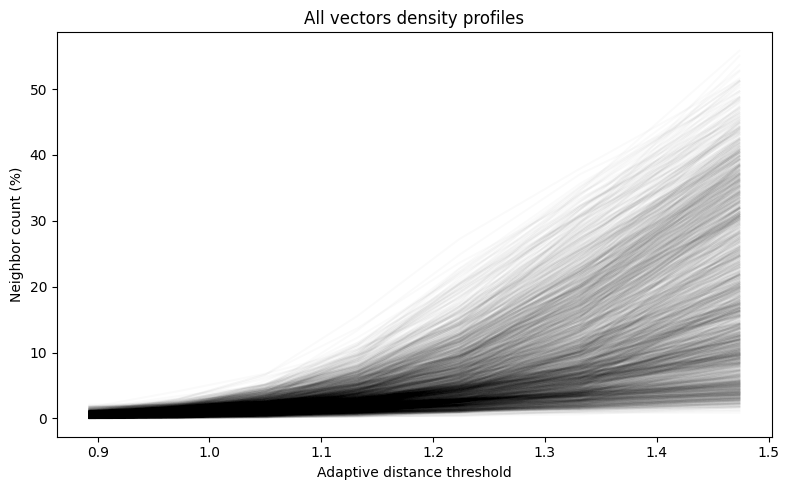

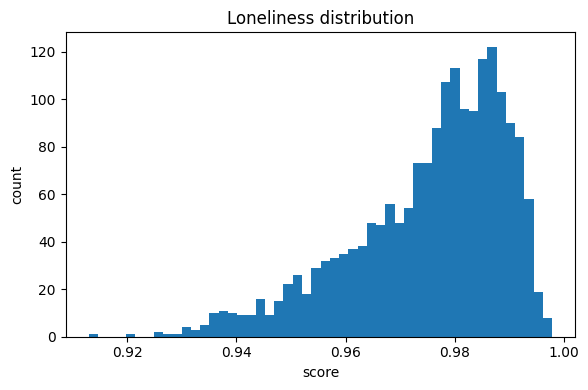

In [28]:
# full cloud visualization
plt.figure(figsize=(8, 5))
for i in range(P):
    plt.plot(thresholds, counts_norm[i], color='black', alpha=0.02)

plt.xlabel("Adaptive distance threshold")
plt.ylabel("Neighbor count (%)")
plt.title("All vectors density profiles")
plt.tight_layout()
plt.show()

# plot loneliness distribution
plt.figure(figsize=(6, 4))
plt.hist(loneliness, bins=50)
plt.title("Loneliness distribution")
plt.xlabel("score")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [29]:
# load yeo
yeo_img = nb.load(gl.conn_dir + f'/maps/yeo17_Icosahedron1002.plabel.nii')
yeo_data = yeo_img.get_fdata().squeeze()
label_dict = yeo_img.header.get_axis(0).label[0]
names = [label_dict[i+1][0] for i in range(17)]
labels_int = yeo_data.astype(int)
label_to_name = {i+1: names[i] for i in range(len(names))}

In [30]:
# rank networks by loneliness
df = pd.DataFrame({
    "label": labels_int,
    "loneliness": loneliness
})
df["name"] = df["label"].map(label_to_name)

group_stats = df.groupby(["name"])["loneliness"].agg(
    mean="mean",
    median="median",
    std="std",
    count="count",
    max="max"
)

ranked = group_stats.sort_values("mean", ascending=False)
print(ranked)

                          mean    median       std  count       max
name                                                               
01.VisualA            0.989542  0.989196  0.003847    125  0.997933
14.TemporalParietal   0.987009  0.987094  0.003639     66  0.997727
05.DorsalAttentionA   0.985881  0.986005  0.006367    111  0.996382
02.VisualB            0.985148  0.985866  0.006316    102  0.995167
15.DefaultC           0.982823  0.988270  0.011469     46  0.995956
12.ControlA           0.982756  0.983058  0.006875    109  0.994285
11.ControlC           0.982551  0.983756  0.007173     43  0.992163
06.DorsalAttentionB   0.981161  0.980936  0.005372    109  0.995685
08.VentralAttentionB  0.974783  0.975262  0.008081     97  0.992196
04.SomatomotorB       0.974134  0.976600  0.011601    146  0.997795
13.ControlB           0.974061  0.975227  0.009238    100  0.993892
07.VentralAttentionA  0.973357  0.975502  0.013032    151  0.996013
17.DefaultB           0.969773  0.971376  0.0141

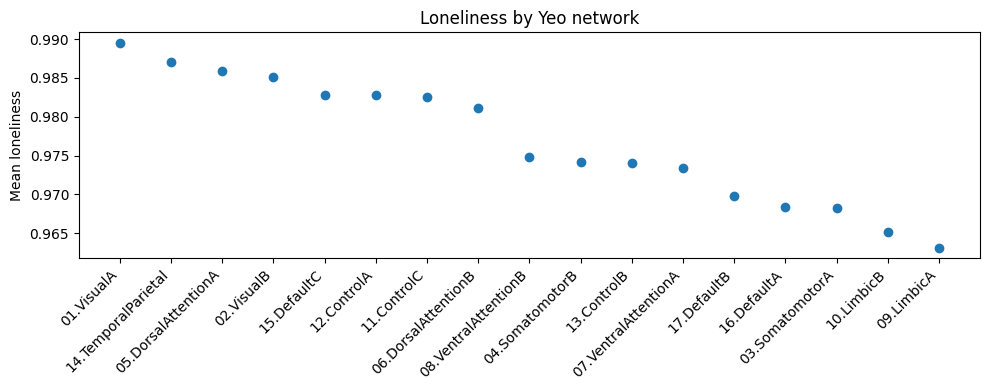

In [31]:
plt.figure(figsize=(10, 4))

plt.scatter(ranked.index, ranked["mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean loneliness")
plt.title("Loneliness by Yeo network")
plt.tight_layout()
plt.show()